In [ ]:
# Import the necessary libraries
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import os
from pyspark.sql.types import *
from pyspark.sql.types import StringType, NumericType, DateType, TimestampType
from pyspark.ml.feature import StringIndexer
import folium
from folium.plugins import HeatMap

#**1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [ ]:
# Write code to load the data and check the schema

spark = (
    SparkSession.builder
    .appName("Traffic Data Analysis")
    .getOrCreate()
)

In [ ]:
# Read collisions dataset
df_collisions = (spark.read.format("csv").option("inferSchame",True).option("header",True)
.load("sample_collisions.csv"))

In [ ]:
df_collisions.count()

935791

In [ ]:
df_collisions.printSchema()

root
 |-- case_id: string (nullable = true)
 |-- jurisdiction: string (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: string (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: string (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: string (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: string (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: string (nullable = true)
 |-- caltrans_county: string (nullable = true)
 |-- caltrans_district: string (nullable = true)
 |-- st

In [ ]:
df_parties = (spark.read.format("csv").option("inferSchame",True).option("header",True)
.load("sample_parties.csv"))

In [ ]:
df_parties.count()

1866917

In [ ]:
df_parties.printSchema()

root
 |-- id: string (nullable = true)
 |-- case_id: string (nullable = true)
 |-- party_number: string (nullable = true)
 |-- party_type: string (nullable = true)
 |-- at_fault: string (nullable = true)
 |-- party_sex: string (nullable = true)
 |-- party_age: string (nullable = true)
 |-- party_sobriety: string (nullable = true)
 |-- direction_of_travel: string (nullable = true)
 |-- party_safety_equipment_1: string (nullable = true)
 |-- party_safety_equipment_2: string (nullable = true)
 |-- financial_responsibility: string (nullable = true)
 |-- cellphone_in_use: string (nullable = true)
 |-- cellphone_use_type: string (nullable = true)
 |-- other_associate_factor_1: string (nullable = true)
 |-- party_number_killed: string (nullable = true)
 |-- party_number_injured: string (nullable = true)
 |-- movement_preceding_collision: string (nullable = true)
 |-- vehicle_year: string (nullable = true)
 |-- vehicle_make: string (nullable = true)
 |-- statewide_vehicle_type: string (nullabl

In [ ]:
df_victims = (spark.read.format("csv").option("inferSchame",True).option("header",True)
.load("sample_victims.csv"))

In [ ]:
df_victims.count()

963933

In [ ]:
df_victims.printSchema()

root
 |-- id: string (nullable = true)
 |-- case_id: string (nullable = true)
 |-- party_number: string (nullable = true)
 |-- victim_role: string (nullable = true)
 |-- victim_sex: string (nullable = true)
 |-- victim_age: string (nullable = true)
 |-- victim_degree_of_injury: string (nullable = true)
 |-- victim_seating_position: string (nullable = true)
 |-- victim_safety_equipment_1: string (nullable = true)
 |-- victim_safety_equipment_2: string (nullable = true)
 |-- victim_ejected: string (nullable = true)



In [ ]:
df_case_ids = (spark.read.format("csv").option("inferSchame",True).option("header",True)
.load("sample_case_ids.csv"))

In [ ]:
df_case_ids.count()

942433

In [ ]:
df_case_ids.printSchema()

root
 |-- case_id: string (nullable = true)
 |-- db_year: string (nullable = true)



#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>

In [ ]:
#Display Schema & Sample Data
df_collisions.printSchema()

root
 |-- case_id: string (nullable = true)
 |-- jurisdiction: string (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: string (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: string (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: string (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: string (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: string (nullable = true)
 |-- caltrans_county: string (nullable = true)
 |-- caltrans_district: string (nullable = true)
 |-- st

In [ ]:
df_collisions.show(5)

+----------+------------+----------+------------------+--------------+----------------+--------------------+---------------+-----------------+-------------------+----------------+--------------+-----------+------------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+--------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+---------------+-----------------+---------------------------+--------------------+------------+----------------+--------------------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----

In [ ]:
df_parties.printSchema()

root
 |-- id: string (nullable = true)
 |-- case_id: string (nullable = true)
 |-- party_number: string (nullable = true)
 |-- party_type: string (nullable = true)
 |-- at_fault: string (nullable = true)
 |-- party_sex: string (nullable = true)
 |-- party_age: string (nullable = true)
 |-- party_sobriety: string (nullable = true)
 |-- direction_of_travel: string (nullable = true)
 |-- party_safety_equipment_1: string (nullable = true)
 |-- party_safety_equipment_2: string (nullable = true)
 |-- financial_responsibility: string (nullable = true)
 |-- cellphone_in_use: string (nullable = true)
 |-- cellphone_use_type: string (nullable = true)
 |-- other_associate_factor_1: string (nullable = true)
 |-- party_number_killed: string (nullable = true)
 |-- party_number_injured: string (nullable = true)
 |-- movement_preceding_collision: string (nullable = true)
 |-- vehicle_year: string (nullable = true)
 |-- vehicle_make: string (nullable = true)
 |-- statewide_vehicle_type: string (nullabl

In [ ]:
df_parties.show(5)

+--------+--------------------+------------+----------+--------+---------+---------+--------------------+-------------------+------------------------+------------------------+------------------------+----------------+--------------------+------------------------+-------------------+--------------------+----------------------------+------------+------------+----------------------+-----------------------+----------------------+----------+
|      id|             case_id|party_number|party_type|at_fault|party_sex|party_age|      party_sobriety|direction_of_travel|party_safety_equipment_1|party_safety_equipment_2|financial_responsibility|cellphone_in_use|  cellphone_use_type|other_associate_factor_1|party_number_killed|party_number_injured|movement_preceding_collision|vehicle_year|vehicle_make|statewide_vehicle_type|chp_vehicle_type_towing|chp_vehicle_type_towed|party_race|
+--------+--------------------+------------+----------+--------+---------+---------+--------------------+-------------

In [ ]:
df_victims.printSchema()

root
 |-- id: string (nullable = true)
 |-- case_id: string (nullable = true)
 |-- party_number: string (nullable = true)
 |-- victim_role: string (nullable = true)
 |-- victim_sex: string (nullable = true)
 |-- victim_age: string (nullable = true)
 |-- victim_degree_of_injury: string (nullable = true)
 |-- victim_seating_position: string (nullable = true)
 |-- victim_safety_equipment_1: string (nullable = true)
 |-- victim_safety_equipment_2: string (nullable = true)
 |-- victim_ejected: string (nullable = true)



In [ ]:
df_victims.show(5)

+-------+----------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|     id|   case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+-------+----------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|2166324| 6324923.0|           1|     driver|      male|      62.0|      complaint of pain|                 driver|     air bag not deployed|     lap/shoulder harn...|   not ejected|
| 779470|  761473.0|           1|  passenger|      male|      25.0|              no injury|       passenger seat 3|     lap/shoulder harn...|                     NULL|   not ejected|
| 742636|  723123.0|           1|     driver|      NULL|      31.0|      complaint of

In [ ]:
df_case_ids.printSchema()

root
 |-- case_id: string (nullable = true)
 |-- db_year: string (nullable = true)



In [ ]:
df_case_ids.count()

942433

##**2.1 Missing Values** <font color = red>[10 marks]</font> <br>

In [ ]:
df_collisions.select([ sum(col(cols).isNull().cast("int")).alias(cols) for cols in df_collisions.columns]).show()

+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-----------

In [ ]:
df_parties.select([ sum(col(cols).isNull().cast("int")).alias(cols) for cols in df_parties.columns]).show()

+---+-------+------------+----------+--------+---------+---------+--------------+-------------------+------------------------+------------------------+------------------------+----------------+------------------+------------------------+-------------------+--------------------+----------------------------+------------+------------+----------------------+-----------------------+----------------------+----------+
| id|case_id|party_number|party_type|at_fault|party_sex|party_age|party_sobriety|direction_of_travel|party_safety_equipment_1|party_safety_equipment_2|financial_responsibility|cellphone_in_use|cellphone_use_type|other_associate_factor_1|party_number_killed|party_number_injured|movement_preceding_collision|vehicle_year|vehicle_make|statewide_vehicle_type|chp_vehicle_type_towing|chp_vehicle_type_towed|party_race|
+---+-------+------------+----------+--------+---------+---------+--------------+-------------------+------------------------+------------------------+-------------------

In [ ]:
df_victims.select([ sum(col(cols).isNull().cast("int")).alias(cols) for cols in df_victims.columns]).show()

+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
| id|case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|  0|      0|           0|          1|     24041|     32145|                      0|                   1913|                    55215|                   310220|          4272|
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+



In [ ]:
df_case_ids.select([ sum(col(cols).isNull().cast("int")).alias(cols) for cols in df_case_ids.columns]).show()

+-------+-------+
|case_id|db_year|
+-------+-------+
|      0|      0|
+-------+-------+



In [ ]:
#Drop Sparse Columns
# Drop column where missing values more than 70%

In [ ]:
total_rows = df_case_ids.count()
df_case_ids.select([ concat(round(sum(col(cols).isNull().cast("int")) / total_rows * 100,2),lit('%')).alias(cols) for cols in df_case_ids.columns]).show()

+-------+-------+
|case_id|db_year|
+-------+-------+
|   0.0%|   0.0%|
+-------+-------+



In [ ]:
total_rows = df_collisions.count()
df_collisions.select([ concat(round(sum(col(cols).isNull().cast("int")) / total_rows * 100,2),lit('%')).alias(cols) for cols in df_collisions.columns]).show()

+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-----------

In [ ]:
total_rows = df_parties.count()
df_parties.select([ concat(round(sum(col(cols).isNull().cast("int")) / total_rows * 100,2),lit('%')).alias(cols) for cols in df_parties.columns]).show()

+----+-------+------------+----------+--------+---------+---------+--------------+-------------------+------------------------+------------------------+------------------------+----------------+------------------+------------------------+-------------------+--------------------+----------------------------+------------+------------+----------------------+-----------------------+----------------------+----------+
|  id|case_id|party_number|party_type|at_fault|party_sex|party_age|party_sobriety|direction_of_travel|party_safety_equipment_1|party_safety_equipment_2|financial_responsibility|cellphone_in_use|cellphone_use_type|other_associate_factor_1|party_number_killed|party_number_injured|movement_preceding_collision|vehicle_year|vehicle_make|statewide_vehicle_type|chp_vehicle_type_towing|chp_vehicle_type_towed|party_race|
+----+-------+------------+----------+--------+---------+---------+--------------+-------------------+------------------------+------------------------+----------------

In [ ]:
total_rows = df_victims.count()
df_victims.select([ concat(round(sum(col(cols).isNull().cast("int")) / total_rows * 100,2),lit('%')).alias(cols) for cols in df_victims.columns]).show()

+----+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|  id|case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+----+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|0.0%|   0.0%|        0.0%|       0.0%|     2.49%|     3.33%|                   0.0%|                   0.2%|                    5.73%|                   32.18%|         0.44%|
+----+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+



In [ ]:
#Convert Data Types
df_collisions_cast_dtype = (
    df_collisions.withColumn("case_id",col("case_id").try_cast("double").try_cast("long"))
    .withColumn("jurisdiction",col("jurisdiction").try_cast("double").try_cast("long"))
    .withColumn("intersection",col("intersection").try_cast("double").try_cast("long"))
    .withColumn("tow_away",col("tow_away").try_cast("double").try_cast("long"))
    .withColumn("killed_victims",col("killed_victims").try_cast("double").try_cast("long"))
    .withColumn("party_count",col("party_count").try_cast("double").try_cast("long"))
    .withColumn("injured_victims",col("injured_victims").try_cast("double").try_cast("long"))
    .withColumn("pcf_violation_subsection",col("pcf_violation_subsection").try_cast("double").try_cast("long"))
    .withColumn("state_highway_indicator",col("state_highway_indicator").try_cast("double").try_cast("long"))
    .withColumn("county_city_location",col("county_city_location").try_cast("double").try_cast("long"))
    .withColumn("special_condition",col("special_condition").try_cast("double").try_cast("long"))
    .withColumn("chp_road_type",col("chp_road_type").try_cast("double").try_cast("long"))
    .withColumn("not_private_property",col("not_private_property").try_cast("double").try_cast("long"))
    .withColumn("latitude",col("latitude").try_cast("double").try_cast("long"))
    .withColumn("motorcyclist_injured_count",col("motorcyclist_injured_count").try_cast("double").try_cast("long"))
    .withColumn("longitude",col("longitude").try_cast("double").try_cast("long"))
    .withColumn("pcf_violation",col("pcf_violation").try_cast("double").try_cast("long"))
    .withColumn("collision_date",to_date(col("collision_date"), "yyyy-MM-dd"))
    .withColumn("collision_time",to_timestamp(col("collision_time"), "HH:mm:ss"))
    .withColumn("process_date",to_date(col("process_date"), "yyyy-MM-dd"))
)

In [ ]:
df_collisions_cast_dtype.printSchema()

root
 |-- case_id: long (nullable = true)
 |-- jurisdiction: long (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: long (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: long (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: string (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: long (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: long (nullable = true)
 |-- caltrans_county: string (nullable = true)
 |-- caltrans_district: string (nullable = true)
 |-- state_route: s

In [ ]:
#Convert Data Types
df_parties_cast_dtype = (
    df_parties.withColumn("case_id",col("case_id").try_cast("double").try_cast("long"))
    .withColumn("id",col("id").try_cast("double").try_cast("long"))
    .withColumn("chp_vehicle_type_towed",col("chp_vehicle_type_towed").try_cast("double").try_cast("long"))
    .withColumn("cellphone_in_use",col("cellphone_in_use").try_cast("double").try_cast("long"))
    .withColumn("vehicle_year",col("vehicle_year").try_cast("double").try_cast("long"))
    .withColumn("party_age",col("party_age").try_cast("double").try_cast("long"))
)

In [ ]:
df_parties_cast_dtype.printSchema()

root
 |-- id: long (nullable = true)
 |-- case_id: long (nullable = true)
 |-- party_number: string (nullable = true)
 |-- party_type: string (nullable = true)
 |-- at_fault: string (nullable = true)
 |-- party_sex: string (nullable = true)
 |-- party_age: long (nullable = true)
 |-- party_sobriety: string (nullable = true)
 |-- direction_of_travel: string (nullable = true)
 |-- party_safety_equipment_1: string (nullable = true)
 |-- party_safety_equipment_2: string (nullable = true)
 |-- financial_responsibility: string (nullable = true)
 |-- cellphone_in_use: long (nullable = true)
 |-- cellphone_use_type: string (nullable = true)
 |-- other_associate_factor_1: string (nullable = true)
 |-- party_number_killed: string (nullable = true)
 |-- party_number_injured: string (nullable = true)
 |-- movement_preceding_collision: string (nullable = true)
 |-- vehicle_year: long (nullable = true)
 |-- vehicle_make: string (nullable = true)
 |-- statewide_vehicle_type: string (nullable = true)


In [ ]:
#Convert Data Types
df_victims_cast_dtype = (
    df_victims.withColumn("id",col("id").try_cast("double").try_cast("long"))
    .withColumn("case_id",col("case_id").try_cast("double").try_cast("long"))
    .withColumn("victim_age",col("victim_age").try_cast("double").try_cast("long"))
    .withColumn("party_number",col("party_number").try_cast("double").try_cast("long"))
)

In [ ]:
df_victims_cast_dtype.printSchema()

root
 |-- id: long (nullable = true)
 |-- case_id: long (nullable = true)
 |-- party_number: long (nullable = true)
 |-- victim_role: string (nullable = true)
 |-- victim_sex: string (nullable = true)
 |-- victim_age: long (nullable = true)
 |-- victim_degree_of_injury: string (nullable = true)
 |-- victim_seating_position: string (nullable = true)
 |-- victim_safety_equipment_1: string (nullable = true)
 |-- victim_safety_equipment_2: string (nullable = true)
 |-- victim_ejected: string (nullable = true)



In [ ]:
#Convert Data Types
df_case_ids_cast_dtype = (
    df_case_ids.withColumn("case_id",col("case_id").try_cast("double").try_cast("long"))
    .withColumn("db_year",col("db_year").try_cast("long"))
)

In [ ]:
df_case_ids_cast_dtype.printSchema()

root
 |-- case_id: long (nullable = true)
 |-- db_year: long (nullable = true)



In [ ]:
#Handle Missing Values
df_collisions_fillna = df_collisions_cast_dtype

for field in df_collisions_cast_dtype.schema.fields:

    if isinstance(field.dataType, StringType):
        df_collisions_fillna = df_collisions_fillna.withColumn(
            field.name,
            coalesce(col(field.name), lit("Unknown"))
        )

    elif isinstance(field.dataType, NumericType):
        df_collisions_fillna = df_collisions_fillna.withColumn(
            field.name,
            coalesce(col(field.name), lit(0))
        )

    elif isinstance(field.dataType, DateType):
        df_collisions_fillna = df_collisions_fillna.withColumn(
            field.name,
            coalesce(
                col(field.name),
                lit("1900-01-01").cast("date")
            )
        )

    elif isinstance(field.dataType, TimestampType):
        df_collisions_fillna = df_collisions_fillna.withColumn(
            field.name,
            coalesce(
                col(field.name),
                lit("1900-01-01 00:00:00").cast("timestamp")
            )
        )

In [ ]:
# No null values in collisions dataset
total_rows = df_collisions_fillna.count()
df_collisions_fillna.select([ concat(round(sum(col(cols).isNull().cast("int")) / total_rows * 100,2),lit('%')).alias(cols) for cols in df_collisions_fillna.columns]).show()

+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-----------

In [ ]:
#Handle Missing Values

avg_party_age = df_parties_cast_dtype.select(
    avg("party_age")
).first()[0]

# Handle Missing Values
df_parties_fillna = df_parties_cast_dtype

for field in df_parties_fillna.schema.fields:

    if isinstance(field.dataType, StringType):
        df_parties_fillna = df_parties_fillna.withColumn(
            field.name,
            coalesce(col(field.name), lit("Unknown"))
        )

    elif field.name == "party_age":
        # Fill missing party_age with average party age
        df_parties_fillna = df_parties_fillna.withColumn(
            field.name,
            coalesce(col(field.name), lit(avg_party_age))
        )

    elif isinstance(field.dataType, NumericType):
        df_parties_fillna = df_parties_fillna.withColumn(
            field.name,
            coalesce(col(field.name), lit(0))
        )

    elif isinstance(field.dataType, DateType):
        df_parties_fillna = df_parties_fillna.withColumn(
            field.name,
            coalesce(
                col(field.name),
                lit("1900-01-01").cast("date")
            )
        )

    elif isinstance(field.dataType, TimestampType):
        df_parties_fillna = df_parties_fillna.withColumn(
            field.name,
            coalesce(
                col(field.name),
                lit("1900-01-01 00:00:00").cast("timestamp")
            )
        )

In [ ]:
# No null values in collisions dataset
total_rows = df_parties_fillna.count()
df_parties_fillna.select([ concat(round(sum(col(cols).isNull().cast("int")) / total_rows * 100,2),lit('%')).alias(cols) for cols in df_parties_fillna.columns]).show()

+----+-------+------------+----------+--------+---------+---------+--------------+-------------------+------------------------+------------------------+------------------------+----------------+------------------+------------------------+-------------------+--------------------+----------------------------+------------+------------+----------------------+-----------------------+----------------------+----------+
|  id|case_id|party_number|party_type|at_fault|party_sex|party_age|party_sobriety|direction_of_travel|party_safety_equipment_1|party_safety_equipment_2|financial_responsibility|cellphone_in_use|cellphone_use_type|other_associate_factor_1|party_number_killed|party_number_injured|movement_preceding_collision|vehicle_year|vehicle_make|statewide_vehicle_type|chp_vehicle_type_towing|chp_vehicle_type_towed|party_race|
+----+-------+------------+----------+--------+---------+---------+--------------+-------------------+------------------------+------------------------+----------------

In [ ]:
#Handle Missing Values
df_victims_fillna = df_victims_cast_dtype

for field in df_victims_fillna.schema.fields:

    if isinstance(field.dataType, StringType):
        df_victims_fillna = df_victims_fillna.withColumn(
            field.name,
            coalesce(col(field.name), lit("Unknown"))
        )

    elif isinstance(field.dataType, NumericType):
        df_victims_fillna = df_victims_fillna.withColumn(
            field.name,
            coalesce(col(field.name), lit(0))
        )

    elif isinstance(field.dataType, DateType):
        df_victims_fillna = df_victims_fillna.withColumn(
            field.name,
            coalesce(
                col(field.name),
                lit("1900-01-01").cast("date")
            )
        )

    elif isinstance(field.dataType, TimestampType):
        df_victims_fillna = df_victims_fillna.withColumn(
            field.name,
            coalesce(
                col(field.name),
                lit("1900-01-01 00:00:00").cast("timestamp")
            )
        )

In [ ]:
# No null values in collisions dataset
total_rows = df_victims_fillna.count()
df_victims_fillna.select([ concat(round(sum(col(cols).isNull().cast("int")) / total_rows * 100,2),lit('%')).alias(cols) for cols in df_victims_fillna.columns]).show()

+----+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|  id|case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+----+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|0.0%|   0.0%|        0.0%|       0.0%|      0.0%|      0.0%|                   0.0%|                   0.0%|                     0.0%|                     0.0%|          0.0%|
+----+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+



In [ ]:
#Handle Missing Values
df_case_ids_fillna = df_case_ids_cast_dtype

for field in df_case_ids_fillna.schema.fields:

    if isinstance(field.dataType, StringType):
        df_case_ids_fillna = df_case_ids_fillna.withColumn(
            field.name,
            coalesce(col(field.name), lit("Unknown"))
        )

    elif isinstance(field.dataType, NumericType):
        df_case_ids_fillna = df_case_ids_fillna.withColumn(
            field.name,
            coalesce(col(field.name), lit(0))
        )

    elif isinstance(field.dataType, DateType):
        df_case_ids_fillna = df_case_ids_fillna.withColumn(
            field.name,
            coalesce(
                col(field.name),
                lit("1900-01-01").cast("date")
            )
        )

    elif isinstance(field.dataType, TimestampType):
        df_case_ids_fillna = df_case_ids_fillna.withColumn(
            field.name,
            coalesce(
                col(field.name),
                lit("1900-01-01 00:00:00").cast("timestamp")
            )
        )

In [ ]:
# No null values in collisions dataset
total_rows = df_case_ids_fillna.count()
df_case_ids_fillna.select([ concat(round(sum(col(cols).isNull().cast("int")) / total_rows * 100,2),lit('%')).alias(cols) for cols in df_case_ids_fillna.columns]).show()

+-------+-------+
|case_id|db_year|
+-------+-------+
|   0.0%|   0.0%|
+-------+-------+



##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>

In [ ]:
#Remove Duplicates

#Find duplicates in collisions dataset
duplicate_collisions_rows = (
    df_collisions_fillna
    .groupBy(df_collisions_fillna.columns)
    .agg(count("*").alias("duplicate_count"))
    .filter(col("duplicate_count") > 1)
)

duplicate_collisions_rows.show()

+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-----------

In [ ]:
duplicate_parties_rows = df_parties_fillna.groupBy(df_parties_fillna.columns).agg(count("*").alias("duplicate_count")).filter("duplicate_count > 1")
duplicate_parties_rows.show()

+---+-------+------------+----------+--------+---------+---------+--------------+-------------------+------------------------+------------------------+------------------------+----------------+------------------+------------------------+-------------------+--------------------+----------------------------+------------+------------+----------------------+-----------------------+----------------------+----------+---------------+
| id|case_id|party_number|party_type|at_fault|party_sex|party_age|party_sobriety|direction_of_travel|party_safety_equipment_1|party_safety_equipment_2|financial_responsibility|cellphone_in_use|cellphone_use_type|other_associate_factor_1|party_number_killed|party_number_injured|movement_preceding_collision|vehicle_year|vehicle_make|statewide_vehicle_type|chp_vehicle_type_towing|chp_vehicle_type_towed|party_race|duplicate_count|
+---+-------+------------+----------+--------+---------+---------+--------------+-------------------+------------------------+------------

In [ ]:
duplicate_victims_rows = df_victims_fillna.groupBy(df_victims_fillna.columns).agg(count("*").alias("duplicate_count")).filter("duplicate_count > 1")
duplicate_victims_rows.show()

+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+---------------+
| id|case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|duplicate_count|
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+---------------+
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+---------------+



In [ ]:
duplicate_case_ids_rows = df_case_ids_fillna.groupBy(df_case_ids_fillna.columns).agg(count("*").alias("duplicate_count")).filter("duplicate_count > 1")
duplicate_victims_rows.show()

+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+---------------+
| id|case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|duplicate_count|
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+---------------+
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+---------------+



In [ ]:
#Detect Outliers using IQR

# Get numeric columns
numeric_cols = [
    field.name
    for field in df_collisions_fillna.schema.fields
    if field.dataType.typeName() in ["integer", "long", "double", "float"]
]

print(numeric_cols)

['case_id', 'jurisdiction', 'county_city_location', 'special_condition', 'intersection', 'state_highway_indicator', 'tow_away', 'killed_victims', 'injured_victims', 'party_count', 'pcf_violation', 'pcf_violation_subsection', 'chp_road_type', 'not_private_property', 'motorcyclist_injured_count', 'latitude', 'longitude']


In [ ]:
# Get numeric columns
numeric_cols = [
    field.name
    for field in df_parties_fillna.schema.fields
    if field.dataType.typeName() in ["integer", "long", "double", "float"]
]

print(numeric_cols)

['id', 'case_id', 'party_age', 'cellphone_in_use', 'vehicle_year', 'chp_vehicle_type_towed']


In [ ]:
# Get numeric columns
numeric_cols = [
    field.name
    for field in df_victims_fillna.schema.fields
    if field.dataType.typeName() in ["integer", "long", "double", "float"]
]

print(numeric_cols)

['id', 'case_id', 'party_number', 'victim_age']


In [ ]:
# Get numeric columns
numeric_cols = [
    field.name
    for field in df_case_ids_fillna.schema.fields
    if field.dataType.typeName() in ["integer", "long", "double", "float"]
]

print(numeric_cols)

['case_id', 'db_year']


##**2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [ ]:
#Remove Outliers

numeric_cols = [
    field.name
    for field in df_collisions_fillna.schema.fields
    if field.dataType.typeName() in ["integer", "long", "double", "float"]
]

df_collisions_clean = df_collisions_fillna

for c in numeric_cols:
    q1, q3 = df_collisions_fillna.approxQuantile(c, [0.25, 0.75], 0.01)

    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df_collisions_clean = df_collisions_clean.filter(
        (col(c) >= lower_bound) &
        (col(c) <= upper_bound)
    )

In [ ]:
print("Original rows:", df_collisions_fillna.count())
print("After removing outliers:", df_collisions_clean.count())

In [ ]:
#Remove Outliers

numeric_cols = [
    field.name
    for field in df_parties_fillna.schema.fields
    if field.dataType.typeName() in ["integer", "long", "double", "float"]
]

df_parties_clean = df_parties_fillna

for c in numeric_cols:
    q1, q3 = df_parties_fillna.approxQuantile(c, [0.25, 0.75], 0.01)

    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df_parties_clean = df_parties_clean.filter(
        (col(c) >= lower_bound) &
        (col(c) <= upper_bound)
    )

In [ ]:
print("Original rows:", df_parties_fillna.count())
print("After removing outliers:", df_parties_clean.count())

Original rows: 1866917
After removing outliers: 1296563


In [ ]:
#Remove Outliers

numeric_cols = [
    field.name
    for field in df_victims_fillna.schema.fields
    if field.dataType.typeName() in ["integer", "long", "double", "float"]
]

df_victims_clean = df_victims_fillna

for c in numeric_cols:
    q1, q3 = df_victims_fillna.approxQuantile(c, [0.25, 0.75], 0.01)

    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df_victims_clean = df_victims_clean.filter(
        (col(c) >= lower_bound) &
        (col(c) <= upper_bound)
    )

In [ ]:
print("Original rows:", df_victims_fillna.count())
print("After removing outliers:", df_victims_clean.count())

Original rows: 963933
After removing outliers: 801808


In [ ]:
#Remove Outliers

numeric_cols = [
    field.name
    for field in df_case_ids_fillna.schema.fields
    if field.dataType.typeName() in ["integer", "long", "double", "float"]
]

df_case_ids_clean = df_case_ids_fillna

for c in numeric_cols:
    q1, q3 = df_case_ids_fillna.approxQuantile(c, [0.25, 0.75], 0.01)

    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df_case_ids_clean = df_case_ids_clean.filter(
        (col(c) >= lower_bound) &
        (col(c) <= upper_bound)
    )

In [ ]:
print("Original rows:", df_case_ids_fillna.count())
print("After removing outliers:", df_case_ids_clean.count())

Original rows: 942433
After removing outliers: 776385


#**3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


##**3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.

In [ ]:
df_collisions_clean.show(5)

In [ ]:
# Encode Categorical Variables

# String Indexing for Categorical Columns

categorical_cols = [
    "chp_shift",
    "special_condition",
    "beat_type",
    "chp_beat_type",
    "chp_beat_class",
    "direction",
    "intersection",
    "weather_1",
    "location_type",
    "side_of_highway",
    "tow_away",
    "collision_severity",
    "primary_collision_factor",
    "pcf_violation_category",
    "hit_and_run",
    "type_of_collision",
    "motor_vehicle_involved_with",
    "pedestrian_action",
    "road_surface",
    "road_condition_1",
    "lighting",
    "control_device",
    "chp_road_type",
    "pedestrian_collision",
    "bicycle_collision",
    "motorcycle_collision",
    "truck_collision",
    "not_private_property",
    "statewide_vehicle_type_at_fault",
    "chp_vehicle_type_at_fault"
]

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_index",
        handleInvalid="keep"
    )
    for c in categorical_cols
]

for indexer in indexers:
    indexer_model = indexer.fit(df_collisions_clean)
    df_collisions_clean = indexer_model.transform(df_collisions_clean)

In [ ]:
df_collisions_clean.show(5)

+-------+------------+----------+------------------+---------+--------------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+--------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+---------------+-----------------+---------------------------+--------------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+----------------------

In [ ]:
categorical_cols = [
    "party_type",
    "at_fault",
    "party_sex",
    "party_sobriety",
    "direction_of_travel",
    "party_safety_equipment_1",
    "party_safety_equipment_2",
    "financial_responsibility",
    "cellphone_in_use",
    "cellphone_use_type",
    "other_associate_factor_1",
    "movement_preceding_collision",
    "vehicle_make",
    "statewide_vehicle_type",
    "chp_vehicle_type_towing",
    "chp_vehicle_type_towed",
    "party_race"
]

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_index",
        handleInvalid="keep"
    )
    for c in categorical_cols
]

for indexer in indexers:
    indexer_model = indexer.fit(df_parties_clean)
    df_parties_clean = indexer_model.transform(df_parties_clean)

In [ ]:
df_parties_clean.show(5)

+-------+-------+------------+--------------+--------+---------+-----------------+--------------------+-------------------+------------------------+------------------------+------------------------+----------------+--------------------+------------------------+-------------------+--------------------+----------------------------+------------+------------+----------------------+-----------------------+----------------------+----------+----------------+--------------+---------------+--------------------+-------------------------+------------------------------+------------------------------+------------------------------+----------------------+------------------------+------------------------------+----------------------------------+------------------+----------------------------+-----------------------------+----------------------------+----------------+
|     id|case_id|party_number|    party_type|at_fault|party_sex|        party_age|      party_sobriety|direction_of_travel|party_safety

In [ ]:
categorical_cols = [
    "victim_role",
    "victim_sex",
    "victim_degree_of_injury",
    "victim_seating_position",
    "victim_safety_equipment_1",
    "victim_safety_equipment_2",
    "victim_ejected"
]

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_index",
        handleInvalid="keep"
    )
    for c in categorical_cols
]

for indexer in indexers:
    indexer_model = indexer.fit(df_victims_clean)
    df_victims_clean = indexer_model.transform(df_victims_clean)

In [ ]:
df_victims_clean.show(5)

+-------+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+-----------------+----------------+-----------------------------+-----------------------------+-------------------------------+-------------------------------+--------------------+
|     id|case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|victim_role_index|victim_sex_index|victim_degree_of_injury_index|victim_seating_position_index|victim_safety_equipment_1_index|victim_safety_equipment_2_index|victim_ejected_index|
+-------+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+-----------------+----------------+-----------------------------+-----------------------------+------

In [ ]:
# Reordering & Renaming Columns

categorical_cols = [
    "chp_shift",
    "special_condition",
    "beat_type",
    "chp_beat_type",
    "chp_beat_class",
    "direction",
    "intersection",
    "weather_1",
    "location_type",
    "side_of_highway",
    "tow_away",
    "collision_severity",
    "primary_collision_factor",
    "pcf_violation_category",
    "hit_and_run",
    "type_of_collision",
    "motor_vehicle_involved_with",
    "pedestrian_action",
    "road_surface",
    "road_condition_1",
    "lighting",
    "control_device",
    "chp_road_type",
    "pedestrian_collision",
    "bicycle_collision",
    "motorcycle_collision",
    "truck_collision",
    "not_private_property",
    "statewide_vehicle_type_at_fault",
    "chp_vehicle_type_at_fault"
]

final_cols = []

for c in df_collisions_clean.columns:
    if c in categorical_cols:
        final_cols.append(c)
        final_cols.append(f"{c}_index")
    elif not c.endswith("_index"):
        final_cols.append(c)

df_collisions_final = df_collisions_clean.select(final_cols)

In [ ]:
df_collisions_final.show(5)

+-------+------------+----------+------------------+---------+---------------+--------------+--------------------+---------------+-----------------+-----------------------+---------+---------------+-------------+-------------------+--------------+--------------------+-----------+------------+--------------+--------+---------+---------------+------------+------------------+---------+---------------+-----------------------+---------------+-----------------+-----------+--------+-------------+-------------------+---------------+---------------------+--------+--------------+--------------------+------------------------+--------------+---------------+-----------+------------------------+------------------------------+----------------------+----------------------------+-------------+------------------------+---------------+-----------------+-----------------+-----------------------+---------------------------+---------------------------------+--------------------+-----------------------+-----

In [ ]:
# Reordering & Renaming Columns

categorical_cols = [
    "party_type",
    "at_fault",
    "party_sex",
    "party_sobriety",
    "direction_of_travel",
    "party_safety_equipment_1",
    "party_safety_equipment_2",
    "financial_responsibility",
    "cellphone_in_use",
    "cellphone_use_type",
    "other_associate_factor_1",
    "movement_preceding_collision",
    "vehicle_make",
    "statewide_vehicle_type",
    "chp_vehicle_type_towing",
    "chp_vehicle_type_towed",
    "party_race"
]

final_cols = []

for c in df_parties_clean.columns:
    if c in categorical_cols:
        final_cols.append(c)
        final_cols.append(f"{c}_index")
    elif not c.endswith("_index"):
        final_cols.append(c)

df_parties_final = df_parties_clean.select(final_cols)

In [ ]:
df_parties_final.show(5)

+-------+-------+------------+--------------+----------------+--------+--------------+---------+---------------+-----------------+--------------------+--------------------+-------------------+-------------------------+------------------------+------------------------------+------------------------+------------------------------+------------------------+------------------------------+----------------+----------------------+--------------------+------------------------+------------------------+------------------------------+-------------------+--------------------+----------------------------+----------------------------------+------------+------------+------------------+----------------------+----------------------------+-----------------------+-----------------------------+----------------------+----------------------------+----------+----------------+
|     id|case_id|party_number|    party_type|party_type_index|at_fault|at_fault_index|party_sex|party_sex_index|        party_age|     

In [ ]:
# Reordering & Renaming Columns

categorical_cols = [
    "victim_role",
    "victim_sex",
    "victim_degree_of_injury",
    "victim_seating_position",
    "victim_safety_equipment_1",
    "victim_safety_equipment_2",
    "victim_ejected"
]

final_cols = []

for c in df_victims_clean.columns:
    if c in categorical_cols:
        final_cols.append(c)
        final_cols.append(f"{c}_index")
    elif not c.endswith("_index"):
        final_cols.append(c)

df_victims_final = df_victims_clean.select(final_cols)

In [ ]:
df_victims_final.show(5)

+-------+-------+------------+-----------+-----------------+----------+----------------+----------+-----------------------+-----------------------------+-----------------------+-----------------------------+-------------------------+-------------------------------+-------------------------+-------------------------------+--------------+--------------------+
|     id|case_id|party_number|victim_role|victim_role_index|victim_sex|victim_sex_index|victim_age|victim_degree_of_injury|victim_degree_of_injury_index|victim_seating_position|victim_seating_position_index|victim_safety_equipment_1|victim_safety_equipment_1_index|victim_safety_equipment_2|victim_safety_equipment_2_index|victim_ejected|victim_ejected_index|
+-------+-------+------------+-----------+-----------------+----------+----------------+----------+-----------------------+-----------------------------+-----------------------+-----------------------------+-------------------------+-------------------------------+---------------

In [ ]:
df_case_ids_clean.show(5)

+-------+-------+
|case_id|db_year|
+-------+-------+
|4078685|   2021|
|3351919|   2018|
| 632208|   2018|
|2465363|   2018|
|6440794|   2021|
+-------+-------+
only showing top 5 rows


##**3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

In [ ]:
# Univariate Analysis

# Collision Severity Distribution

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Convert to Pandas
df_severity_counts_pd = df_collisions_final.groupBy("collision_severity").count().toPandas()

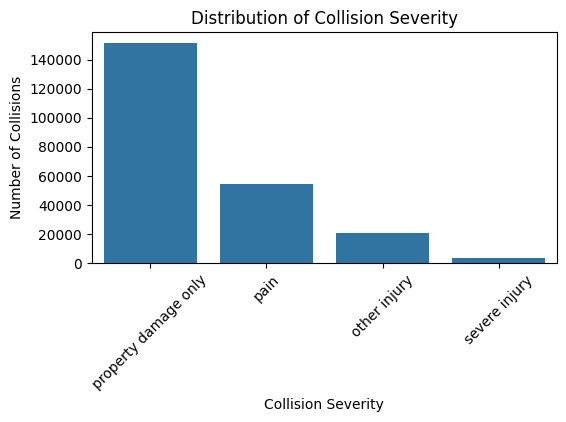

In [ ]:
# Plot
plt.figure(figsize=(6, 3))
sns.barplot(data=df_severity_counts_pd,x="collision_severity",y="count")

plt.title("Distribution of Collision Severity")
plt.xlabel("Collision Severity")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.show()

##**3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

In [ ]:
# Weather Conditions During Collisions

# Convert to Pandas

df_weather_counts_pd = (df_collisions_final.groupBy("weather_1").count().orderBy("count", ascending=False).toPandas())

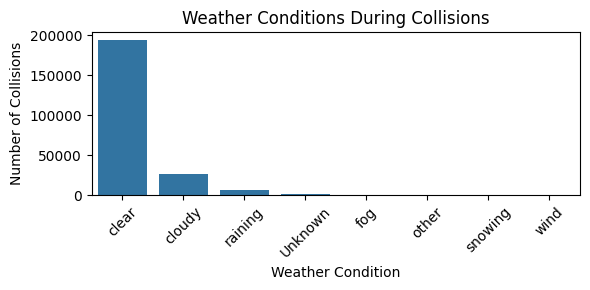

In [ ]:
# Plot
plt.figure(figsize=(6, 3))
sns.barplot(data=df_weather_counts_pd,x="weather_1",y="count")
plt.title("Weather Conditions During Collisions")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##**3.1.4. Victime Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

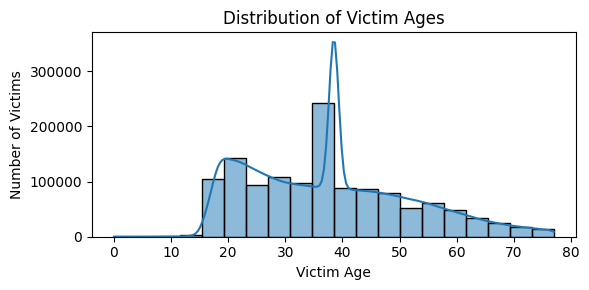

In [ ]:
# Distribution of Victim Ages

# Convert to Pandas
age_data = df_parties_final.select("party_age").toPandas()

# Plot
plt.figure(figsize=(6, 3))
sns.histplot(data=age_data,x="party_age",bins=20,kde=True)
plt.title("Distribution of Victim Ages")
plt.xlabel("Victim Age")
plt.ylabel("Number of Victims")
plt.tight_layout()
plt.show()

##**3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

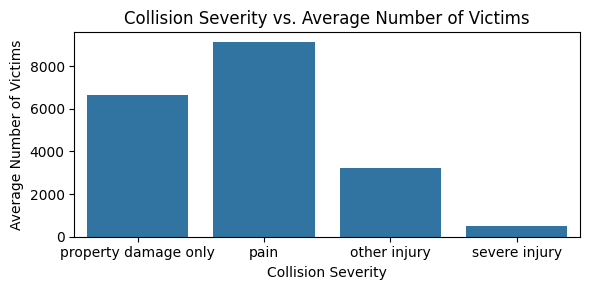

In [ ]:
# Bivariate Analysis

# Collision Severity vs. Number of Victims

# Count victims for each collision
victim_counts = (df_victims_final.groupBy("case_id").agg(count("id").alias("number_of_victims")))

# Join with collision severity
severity_victims = (df_collisions_final.select("case_id", "collision_severity").join(victim_counts, on="case_id", how="inner"))

# Convert to Pandas
severity_victims_pd = (severity_victims.groupBy("collision_severity").agg(sum("number_of_victims").alias("number_of_victims"))
    .toPandas())

# Plot
plt.figure(figsize=(6, 3))
sns.barplot(data=severity_victims_pd,x="collision_severity",y="number_of_victims")
plt.title("Collision Severity vs. Average Number of Victims")
plt.xlabel("Collision Severity")
plt.ylabel("Average Number of Victims")
plt.tight_layout()
plt.show()

##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

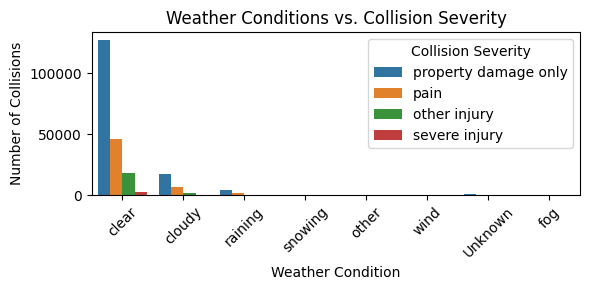

In [ ]:
# Weather vs. Collision Severity

# Convert to Pandas
weather_severity = (df_collisions_final.select("weather_1", "collision_severity").dropna().toPandas())

# Plot
plt.figure(figsize=(6, 3))
sns.countplot(data=weather_severity,x="weather_1",hue="collision_severity")
plt.title("Weather Conditions vs. Collision Severity")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.legend(title="Collision Severity")
plt.tight_layout()
plt.show()

##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

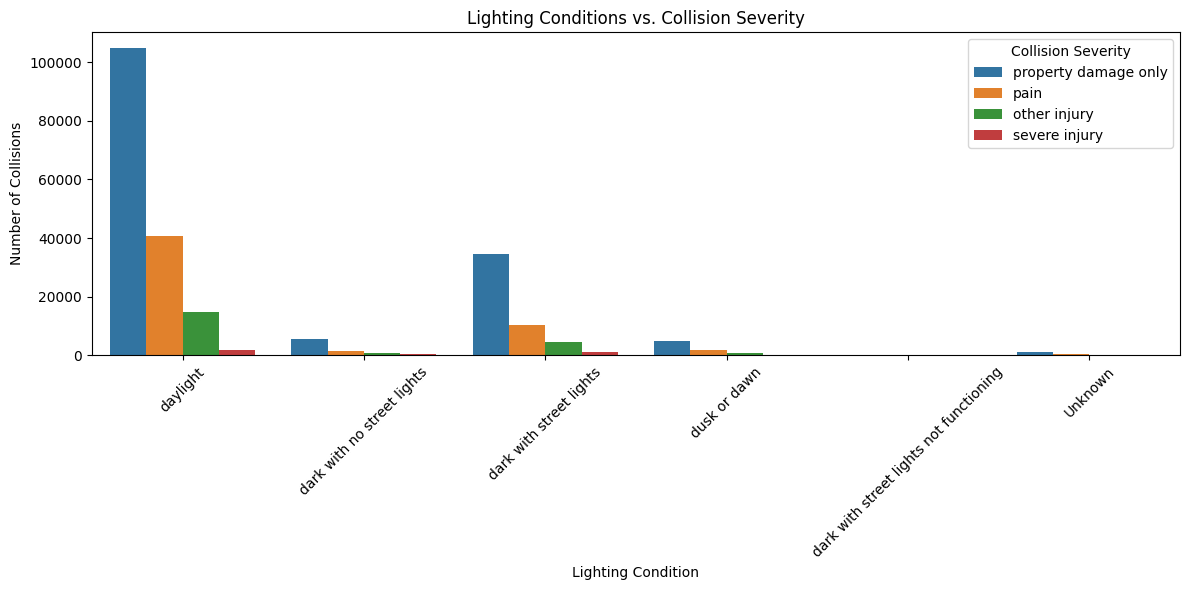

In [ ]:
# Lighting Conditions vs. Collision Severity

# Convert to Pandas
lighting_severity = (df_collisions_final.select("lighting", "collision_severity").dropna().toPandas())

# Plot
plt.figure(figsize=(12, 6))
sns.countplot(data=lighting_severity,x="lighting",hue="collision_severity")
plt.title("Lighting Conditions vs. Collision Severity")
plt.xlabel("Lighting Condition")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.legend(title="Collision Severity")
plt.tight_layout()
plt.show()

##**3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

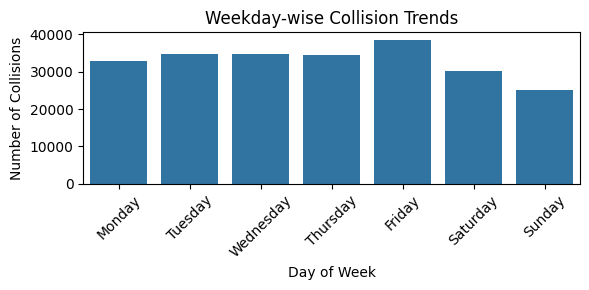

In [ ]:
# Extract the weekday
df_weekday = (df_collisions_final.withColumn("weekday", date_format(col("collision_date"), "EEEE")))

# Count collisions by weekday
weekday_counts = (df_weekday.groupBy("weekday").count())

# Convert to Pandas
weekday_pd = weekday_counts.toPandas()

# Define correct weekday order
weekday_order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]

weekday_pd["weekday"] = pd.Categorical(weekday_pd["weekday"],categories=weekday_order,ordered=True)

weekday_pd = weekday_pd.sort_values("weekday")

# Plot
plt.figure(figsize=(6, 3))
sns.barplot(data=weekday_pd,x="weekday",y="count")
plt.title("Weekday-wise Collision Trends")
plt.xlabel("Day of Week")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##**3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

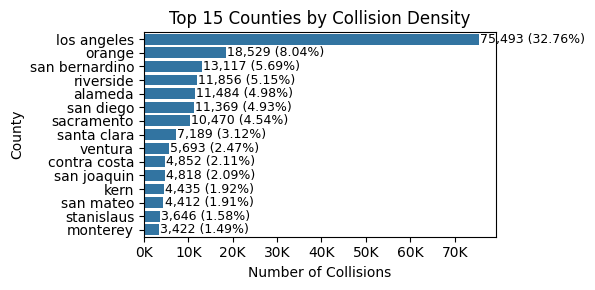

In [ ]:
# Spatial Analysis
# Collision Density by County

# Convert to Pandas
county_counts = (df_collisions_final.groupBy("county_location").count().orderBy("count", ascending=False).toPandas())

# Calculate percentage
total_collisions = county_counts["count"].sum()

county_counts["percentage"] = (county_counts["count"] / total_collisions * 100)

# Top 15 counties
top_counties = county_counts.head(15)

# Plot
plt.figure(figsize=(6, 3))
ax = sns.barplot(data=top_counties,x="count",y="county_location")
# Format x-axis as thousands
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)
# Add count + percentage labels
for i, row in top_counties.reset_index(drop=True).iterrows():
    ax.text(
        row["count"] + total_collisions * 0.001,
        i,
        f'{int(row["count"]):,} ({row["percentage"]:.2f}%)',
        va="center",
        fontsize=9
    )
plt.title("Top 15 Counties by Collision Density")
plt.xlabel("Number of Collisions")
plt.ylabel("County")
plt.tight_layout()
plt.show()

##**3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

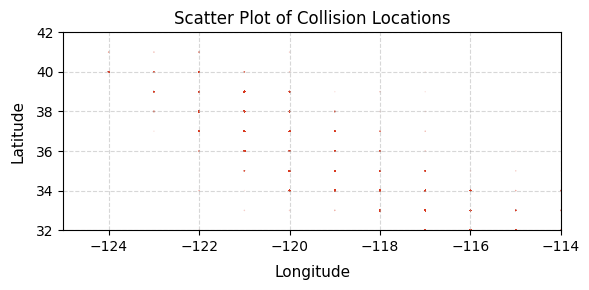

In [ ]:
# Scatter Plot of Collision Locations

# Convert to Pandas
location_pd = (df_collisions_final.select("latitude", "longitude").toPandas())

# Convert to numeric
location_pd["latitude"] = pd.to_numeric(
    location_pd["latitude"], errors="coerce")

location_pd["longitude"] = pd.to_numeric(
    location_pd["longitude"], errors="coerce")

# Remove invalid coordinates
location_pd = location_pd[
    (location_pd["latitude"].between(32, 42)) &
    (location_pd["longitude"].between(-125, -114))
]

# Plot
plt.figure(figsize=(6, 3))
plt.scatter(location_pd["longitude"],location_pd["latitude"],c='#d9381e',s=1.2,alpha=0.12,edgecolors="none",rasterized=True)
plt.title("Scatter Plot of Collision Locations")
plt.xlabel("Longitude",fontsize=11,labelpad=8)
plt.ylabel("Latitude",fontsize=11,labelpad=8)
plt.xlim(-125, -114)
plt.ylim(32, 42)
plt.grid(True, linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

##**3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

In [ ]:
# Extract year and month from collision_date
df_time = (df_collisions_final
    .withColumn("collision_year", year(col("collision_date")))
    .withColumn("collision_month", month(col("collision_date")))
    .withColumn("collision_hour",hour(to_timestamp(col("collision_time"), "HH:mm:ss"))))

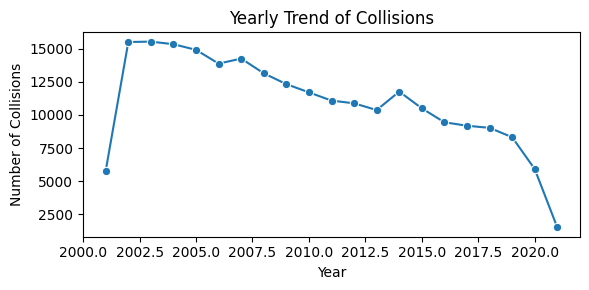

In [ ]:
# Yearly Trend of Collisions

yearly_collisions = (df_time.groupBy("collision_year").count().orderBy("collision_year").toPandas())

plt.figure(figsize=(6, 3))
sns.lineplot(data=yearly_collisions,x="collision_year",y="count",marker="o")
plt.title("Yearly Trend of Collisions")
plt.xlabel("Year")
plt.ylabel("Number of Collisions")
plt.tight_layout()
plt.show()

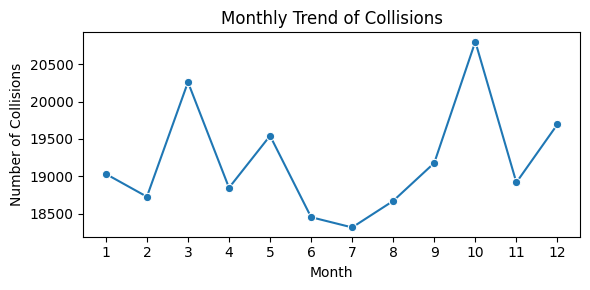

In [ ]:
# Monthly Trend of Collisions

monthly_collisions = (df_time.groupBy("collision_month").count().orderBy("collision_month").toPandas())

plt.figure(figsize=(6, 3))
sns.lineplot(data=monthly_collisions,x="collision_month",y="count",marker="o")
plt.title("Monthly Trend of Collisions")
plt.xlabel("Month")
plt.ylabel("Number of Collisions")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

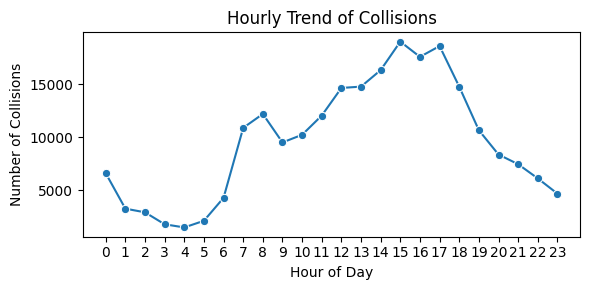

In [ ]:
# Hourly Trend of Collisions

hourly_collisions = (df_time.groupBy("collision_hour").count().orderBy("collision_hour").toPandas())

plt.figure(figsize=(6, 3))
sns.lineplot(data=hourly_collisions,x="collision_hour",y="count",marker="o")
plt.title("Hourly Trend of Collisions")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Collisions")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

#**4. ETL Querying** <font color = red>[35 marks]</font> <br>

## **4.1. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [ ]:
# Query: Identify the top 5 counties with the most collisions
top_5_counties = df_collisions_final.groupBy("county_location").agg(count("*").alias("count")).orderBy(col("count").desc()).limit(5)
top_5_counties.show(5)

+---------------+-----+
|county_location|count|
+---------------+-----+
|    los angeles|75493|
|         orange|18529|
| san bernardino|13117|
|      riverside|11856|
|        alameda|11484|
+---------------+-----+



## **4.2. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [ ]:
# Query: Find the month with the highest number of collisions
df_collisions_final_mnth = df_collisions_final.withColumn("collision_month",date_format("collision_date","MMMM"))
highest_collision_month = (df_collisions_final_mnth.groupBy("collision_month").agg(count("*").alias("count"))
.orderBy(col("count").desc()).limit(1))
highest_collision_month.show()

+---------------+-----+
|collision_month|count|
+---------------+-----+
|        October|20802|
+---------------+-----+



## **4.3. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

In [ ]:
# Query: Find the most common weather condition during collisions
most_common_weather = df_collisions_final.groupBy("weather_1").agg(count("*").alias("count")).orderBy(col("count").desc()).limit(1)
most_common_weather.show()

+---------+------+
|weather_1| count|
+---------+------+
|    clear|193852|
+---------+------+



## **4.4. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [ ]:
# Query: Determine the percentage of collisions that resulted in fatalities
total_collisions = df_collisions_final.count()
fatal_collisions = df_collisions_final.filter("killed_victims > 0 ").count()


fatality_percentage = (fatal_collisions / total_collisions) * 100
print(f"Percentage of collisions that resulted in fatalities: {fatality_percentage:.2f}%")

Percentage of collisions that resulted in fatalities: 0.00%


## **4.5. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

In [250]:
# Query: Find the most dangerous time of day for collisions
hourly_collisions = (df_collisions_final.withColumn("collision_hour",hour(to_timestamp(col("collision_time"), "HH:mm:ss")))
    .groupBy("collision_hour").count().orderBy(col("count").desc()))

# Most dangerous hour
hourly_collisions.limit(1).show()

+--------------+-----+
|collision_hour|count|
+--------------+-----+
|            15|19046|
+--------------+-----+



## **4.6. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [251]:
top_5_road_surface = df_collisions_final.groupBy("road_surface").agg(count("*").alias("count")).orderBy(col("count").desc()).limit(5)
top_5_road_surface.show()

+------------+------+
|road_surface| count|
+------------+------+
|         dry|211567|
|         wet| 15770|
|     Unknown|  2288|
|       snowy|   677|
|    slippery|   131|
+------------+------+



## **4.7. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [254]:
# Query: Find the top 3 lighting conditions that lead to the most collisions
top_3_lighting_collisions = df_collisions_final.groupBy("lighting").agg(count("*").alias("count")).orderBy(col("count").desc()).limit(3)
top_3_lighting_collisions.show(10,False)

+--------------------------+------+
|lighting                  |count |
+--------------------------+------+
|daylight                  |162424|
|dark with street lights   |50567 |
|dark with no street lights|8145  |
+--------------------------+------+



#5. Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

In [255]:
# Final insights and recommendations

The analysis of the California collision dataset reveals several important patterns related to <b>location, time, weather, road surface, lighting conditions, and fatalities</b>. These findings provide useful insights into the factors and areas associated with a high frequency of collisions.

## <b>1. Top Counties</b>

<b>Los Angeles County</b> recorded the highest number of collisions, with <b>75,493 collisions</b>. It was followed by <b>Orange County (18,529)</b>, <b>San Bernardino County (13,117)</b>, <b>Riverside County (11,856)</b>, and <b>Alameda County (11,484)</b>.

The significantly higher number of collisions in Los Angeles County may be associated with its <b>large population, high traffic volume, extensive road network, and greater number of vehicles</b>. The concentration of collisions in these counties suggests that highly populated and heavily trafficked areas experience a greater number of reported collisions.

## <b>2. Month with the Highest Number of Collisions</b>

<b>October</b> recorded the highest number of collisions, with <b>20,802 collisions</b>. This indicates that October had the greatest collision frequency among the months in the dataset.

However, this result represents <b>collision frequency rather than collision severity</b>. A higher number of collisions in October does not necessarily mean that October had more severe or fatal accidents.

## <b>3. Weather Conditions</b>

<b>Clear weather</b> was the most common weather condition during collisions, with <b>193,852 collisions</b>. This indicates that most collisions occurred under normal weather conditions rather than during adverse conditions such as rain, snow, or fog.

The high number of collisions under clear weather does not necessarily mean that <b>clear weather is more dangerous</b>. It may simply reflect the fact that most driving occurs under clear weather conditions.

## <b>4. Fatal Collisions</b>

The analysis calculated the percentage of collisions resulting in fatalities as <b>0.00%</b>, based on the condition <b>killed_victims &gt; 0</b>.

This result should be interpreted carefully. The very low percentage may indicate that fatal collisions represent a very small proportion of the dataset. However, it is also important to <b>validate the killed_victims column</b> to ensure that missing values, data types, or preprocessing did not affect the result.

## <b>5. Most Dangerous Time of Day</b>

The analysis identified <b>3:00 PM (15:00)</b> as the time with the highest number of collisions, with <b>19,046 collisions</b>.

This may be related to increased traffic during the <b>afternoon commute, school-related travel, and other peak travel activities</b>. However, this represents the highest collision frequency and does not necessarily mean that 3:00 PM has the highest collision risk per vehicle.

## <b>6. Road Surface Conditions</b>

<b>Dry roads</b> had the highest collision frequency, with <b>211,567 collisions</b>, followed by <b>wet roads (15,770)</b>, <b>unknown conditions (2,288)</b>, <b>snowy roads (677)</b>, and <b>slippery roads (131)</b>.

The large number of collisions on dry roads is likely because dry conditions are the most common road condition. Therefore, this does not necessarily mean that <b>dry roads are more dangerous</b> than wet or snowy roads.

## <b>7. Lighting Conditions</b>

<b>Daylight</b> was associated with the highest number of collisions, with <b>162,424 collisions</b>. It was followed by <b>dark conditions with street lights (50,567)</b> and <b>dark conditions with no street lights (8,145)</b>.

The high number of collisions during daylight is likely related to the fact that most vehicles operate during daylight hours. However, the number of collisions occurring under <b>dark conditions</b> highlights the importance of visibility and adequate street lighting for nighttime driving.

# <b>Overall Conclusion</b>

Overall, the analysis shows that collision frequency is concentrated in <b>highly populated and heavily trafficked counties</b>, with <b>Los Angeles County</b> having the highest number of collisions.

The highest collision frequency was observed in <b>October</b> and at approximately <b>3:00 PM</b>. Most collisions occurred under <b>clear weather, dry road surfaces, and daylight conditions</b>. These conditions are also likely to be the most common driving conditions, so their high collision counts should not automatically be interpreted as higher risk.

The analysis also highlights the importance of examining <b>wet road conditions and nighttime lighting</b> because reduced traction and visibility can potentially affect driving safety.

Finally, the <b>0.00% fatality result should be validated</b> by checking the underlying `killed_victims` data. Overall, these findings can help identify <b>high-collision locations, peak travel periods, and environmental conditions</b> that can be further investigated to improve road safety and reduce collisions.